# Import the important libraries

In [365]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = r"E:\Datasets\housing"

# Read Dataset

In [366]:
df = pd.read_csv(f"{path}\\housing.csv")

# Understand the features

1. longitude: A measure of how far west a block is; a higher value is farther west
2. latitude: A measure of how far north a block is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the block w.r.t ocean/sea

# EAD

## Basic Dataset Exploration
- How many rows and columns are in the dataset?
- What are the data types of each column?
- Are there any missing values?
- Are there any duplicate rows?
- What are the descriptive statistics of the numerical features?
- What is the range (min–max) of each numerical feature?
- Which features have the highest and lowest standard deviation?

In [367]:
df.shape[0]

20640

In [368]:
df.shape[1]

10

In [369]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [370]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [371]:
df.duplicated().sum()

np.int64(0)

In [372]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')

In [373]:
categorical_features = df.select_dtypes(include=['str']).columns
categorical_features

Index(['ocean_proximity'], dtype='str')

In [374]:
df[numerical_features].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [375]:
df[numerical_features].agg(['min', 'max'])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
min,-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0
max,-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0


In [376]:
numerical_features_std = df[numerical_features].std().sort_values()
max_std = (numerical_features_std.index[-1], numerical_features_std.iloc[-1])
min_std = (numerical_features_std.index[0], numerical_features_std.iloc[0])
max_std

('median_house_value', np.float64(115395.61587441387))

In [377]:
min_std

('median_income', np.float64(1.8998217179452688))

### Dropping the rows with null values

In [378]:
df = df.dropna()

In [379]:
df.shape

(20433, 10)

In [380]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Target Variable — MedHouseVal
- What is the distribution of MedHouseVal?
- Is MedHouseVal normally distributed or skewed?
- What are the mean, median, minimum, and maximum house values?
- Are there potential outliers in MedHouseVal?
- Does the target variable appear to have a ceiling or floor?

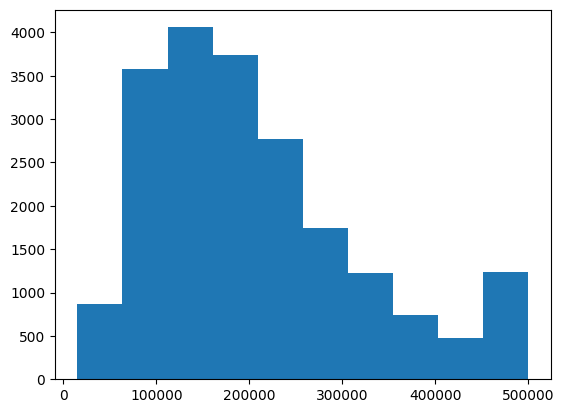

In [381]:
plt.hist(df['median_house_value'])
plt.show()

In [382]:
print("""
the median_house_value is slightly skew to right
""")


the median_house_value is slightly skew to right



In [383]:
df['median_house_value'].agg(['mean', 'median', 'min', 'max'])

mean      206864.413155
median    179700.000000
min        14999.000000
max       500001.000000
Name: median_house_value, dtype: float64

In [384]:
Q1 = df['median_house_value'].quantile(0.25) 
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
large_bound = Q3 + 1.5 * IQR
small_potential_outliers = df[df['median_house_value'] < lower_bound]
large_potential_outliers = df[df['median_house_value'] > large_bound]
small_potential_outliers.shape[0]

0

In [385]:
large_potential_outliers.shape[0]

1064

In [386]:
min_value = df['median_house_value'].min()
max_value = df['median_house_value'].max()
df[df['median_house_value'] == min_value].shape[0]

4

In [387]:
df[df['median_house_value'] == max_value].shape[0]

958

In [388]:
print("""
- No strong evidence of a floor — only 4 rows at the minimum, likely just naturally low values
- Strong evidence of a ceiling — 958 rows (~4.7%) share the exact max value, indicating median_house_value is capped at $500,001
""")


- No strong evidence of a floor — only 4 rows at the minimum, likely just naturally low values
- Strong evidence of a ceiling — 958 rows (~4.7%) share the exact max value, indicating median_house_value is capped at $500,001



## Feature Distributions
For each numerical feature:
- What is the distribution of MedInc?
- What is the distribution of HouseAge?
- What is the distribution of AveRooms?
- What is the distribution of AveBedrms?
- What is the distribution of Population?
- What is the distribution of AveOccup?
- What is the distribution of Latitude and Longitude?

Then ask:
- Which features appear highly skewed?
- Which features contain potential outliers?
- Which features have unusual or extreme values?

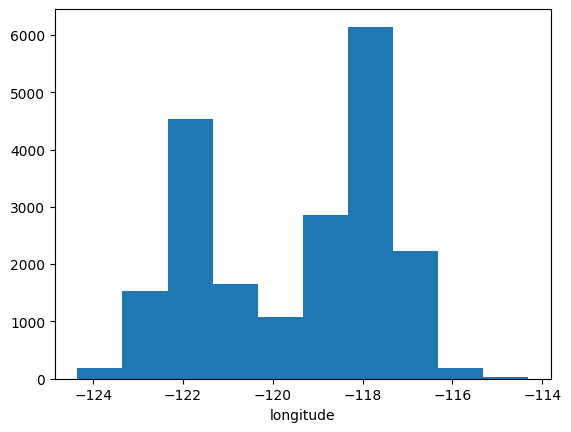

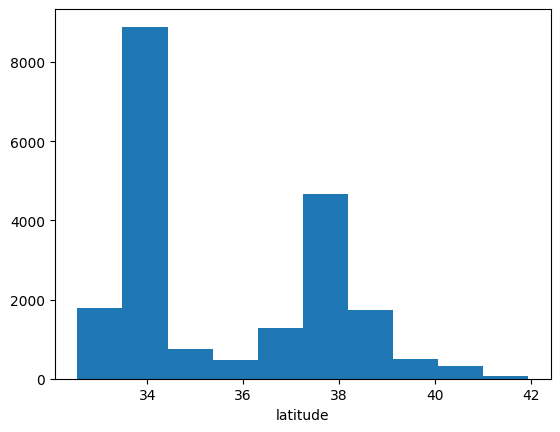

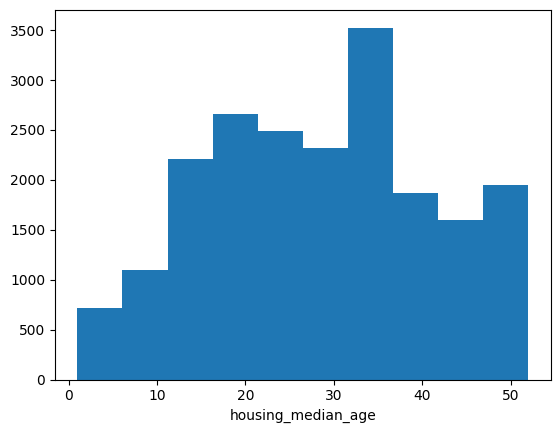

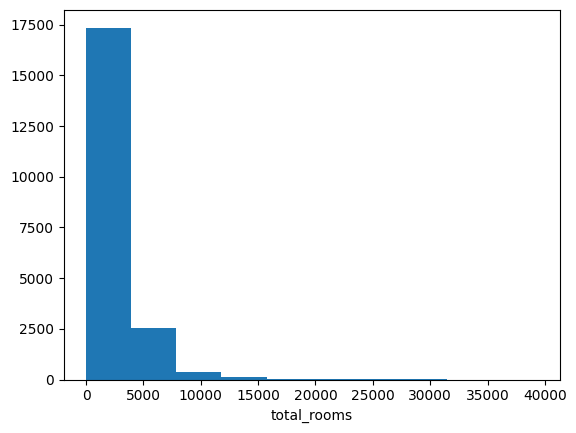

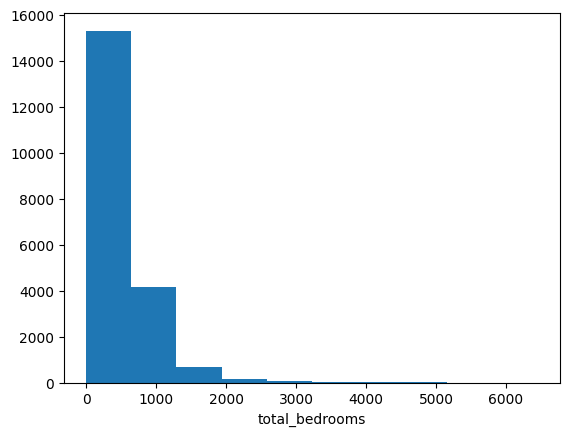

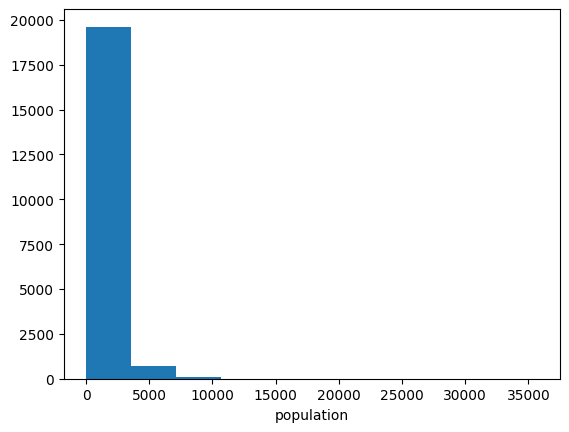

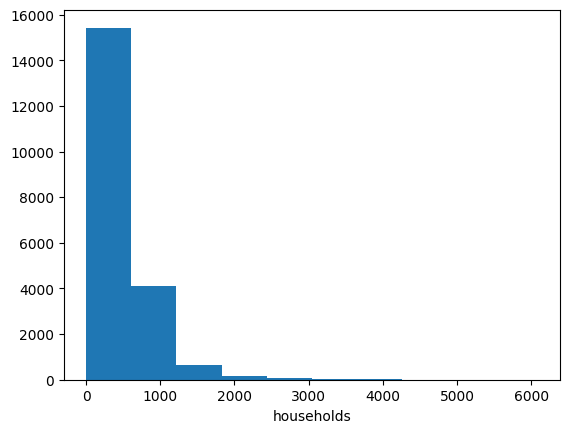

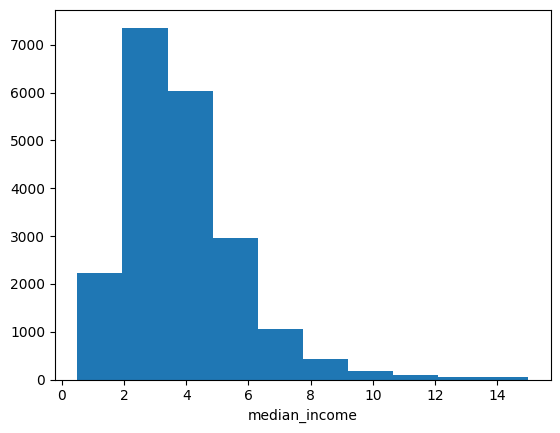

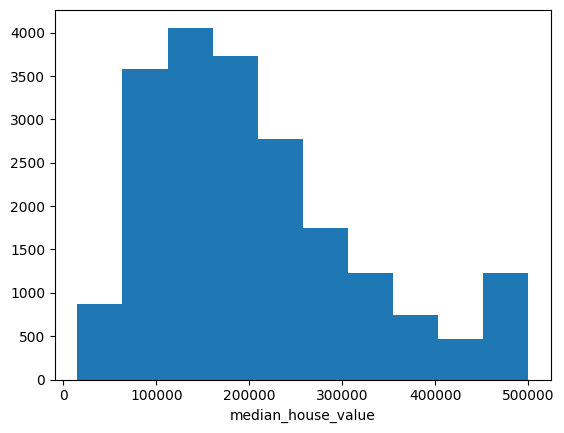

In [389]:
for feature in numerical_features:
    plt.hist(df[feature])
    plt.xlabel(feature)
    plt.show()

In [390]:
print("""
- longitude -> Bimodal distibution
- latitude -> Bimodal distibution
- housing_median_age -> nearly normal
- total_rooms -> skew right
- total_bedrooms -> skew right
- population -> skew right
- households -> skew right
- median_income -> nearly normal
- median_house_value -> skew right
""")


- longitude -> Bimodal distibution
- latitude -> Bimodal distibution
- housing_median_age -> nearly normal
- total_rooms -> skew right
- total_bedrooms -> skew right
- population -> skew right
- households -> skew right
- median_income -> nearly normal
- median_house_value -> skew right



In [391]:
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    large_bound = Q3 + 1.5 * IQR
    small_potential_outliers = df[df[feature] < lower_bound]
    large_potential_outliers = df[df[feature] > large_bound]
    total_outliers = small_potential_outliers.shape[0] + large_potential_outliers.shape[0]
    print(f"the total potential outliers of \033[1m{feature}: {total_outliers}\033[0m")

the total potential outliers of longitude: 0
the total potential outliers of latitude: 0
the total potential outliers of housing_median_age: 0
the total potential outliers of total_rooms: 1290
the total potential outliers of total_bedrooms: 1271
the total potential outliers of population: 1190
the total potential outliers of households: 1210
the total potential outliers of median_income: 670
the total potential outliers of median_house_value: 1064


In [392]:
print("""
- population: it has extremely small values; some blocks have only 1, 3, 5, 6, or 8 people.

- households: it has extremely small values; some blocks have only 1, 2, 4, 5, or 6 households.

- median_income: it has unusual values, with many blocks having exactly the same values:
    - 12 blocks with 0.4999
    - 10 blocks with 0.5360
    - 48 blocks with 15.0001
- median_house_value: it has an unusual repeated value:
    - 958 blocks have a value of 500001.0
""")


- population: it has extremely small values; some blocks have only 1, 3, 5, 6, or 8 people.

- households: it has extremely small values; some blocks have only 1, 2, 4, 5, or 6 households.

- median_income: it has unusual values, with many blocks having exactly the same values:
    - 12 blocks with 0.4999
    - 10 blocks with 0.5360
    - 48 blocks with 15.0001
- median_house_value: it has an unusual repeated value:
    - 958 blocks have a value of 500001.0



## Relationship With the Target
These are particularly important for regression.
- How does MedInc relate to MedHouseVal?
- How does HouseAge relate to MedHouseVal?
- How does AveRooms relate to MedHouseVal?
- How does AveBedrms relate to MedHouseVal?
- How does Population relate to MedHouseVal?
- How does AveOccup relate to MedHouseVal?
- How does location (Latitude, Longitude) relate to house value?
- Which feature appears to have the strongest relationship with MedHouseVal?
- Are the relationships approximately linear or nonlinear?

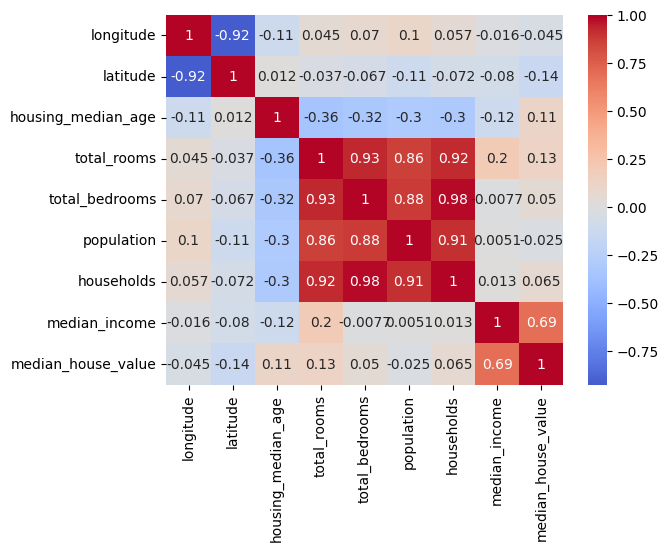

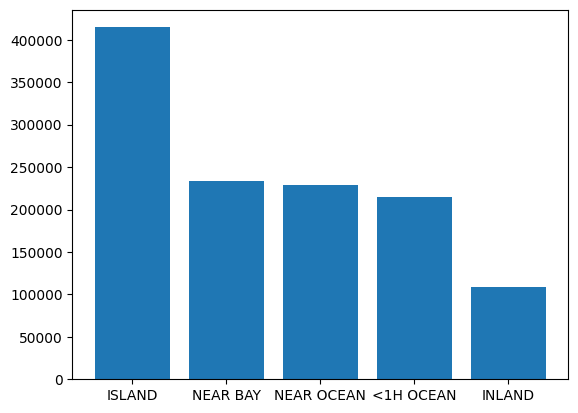


the correlation between numerical features and median_house_value
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64
the correlation between categorical features (ocean_proximity) and median_house_value:
the typical median_house_value in each place is as follows
ocean_proximity
ISLAND        414700.0
NEAR BAY      233800.0
NEAR OCEAN    228750.0
<1H OCEAN     215000.0
INLAND        108700.0
Name: median_house_value, dtype: float64



In [393]:
numerical_features_corr = df[numerical_features].corr()
sns.heatmap(numerical_features_corr, annot=True, cmap='coolwarm', center=0)
mhv = numerical_features_corr['median_house_value'].drop(index='median_house_value')
plt.show()
ocean_proximity_corr = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False)
plt.bar(ocean_proximity_corr.index, ocean_proximity_corr)
plt.show()
print(f"""
the correlation between numerical features and median_house_value
{mhv.sort_values(ascending=False)}
the correlation between categorical features (ocean_proximity) and median_house_value:
the typical median_house_value in each place is as follows
{ocean_proximity_corr}
""")

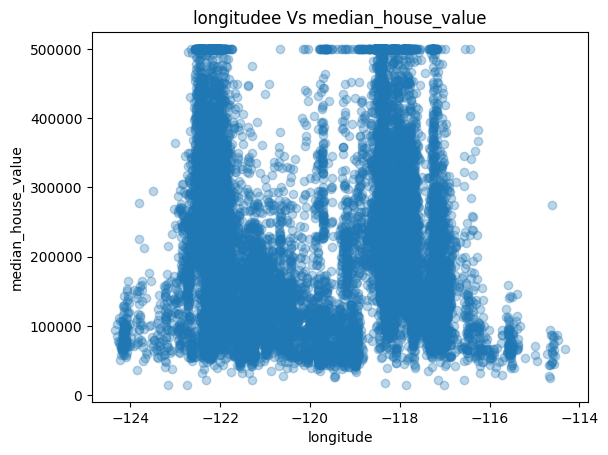

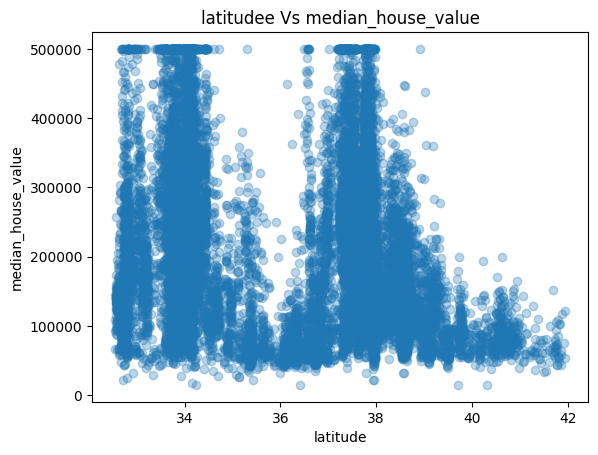

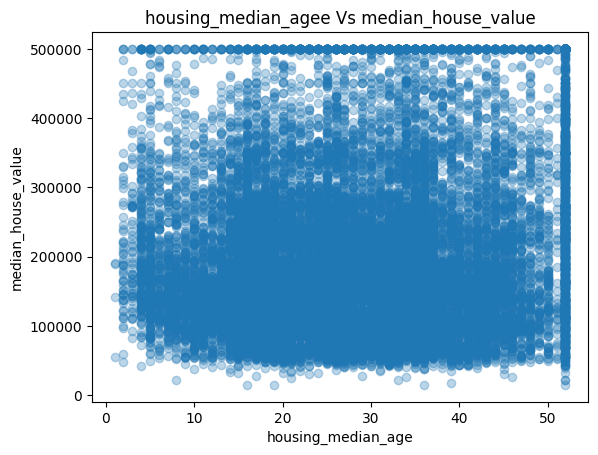

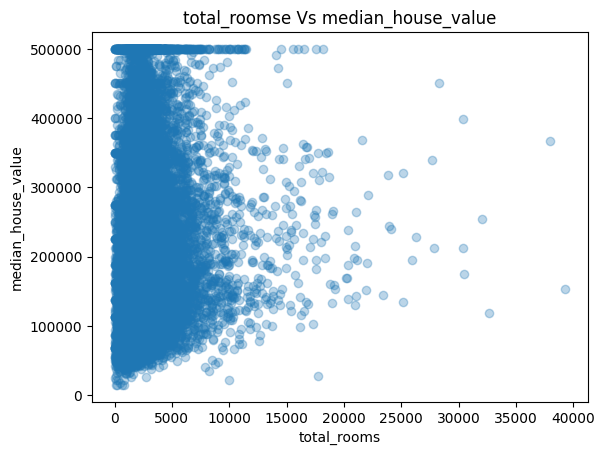

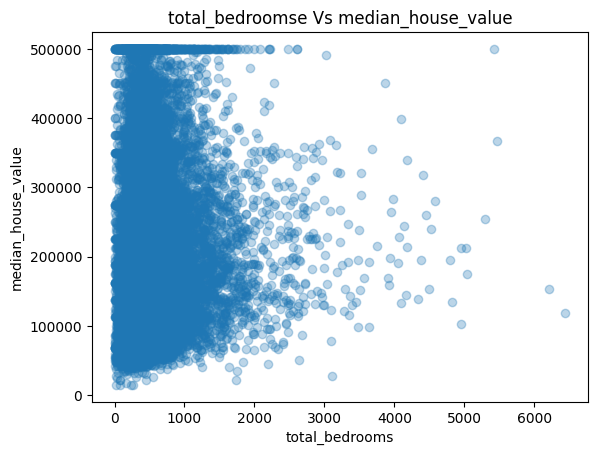

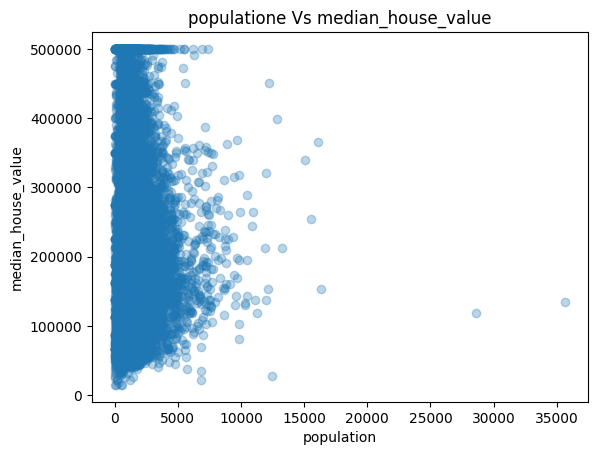

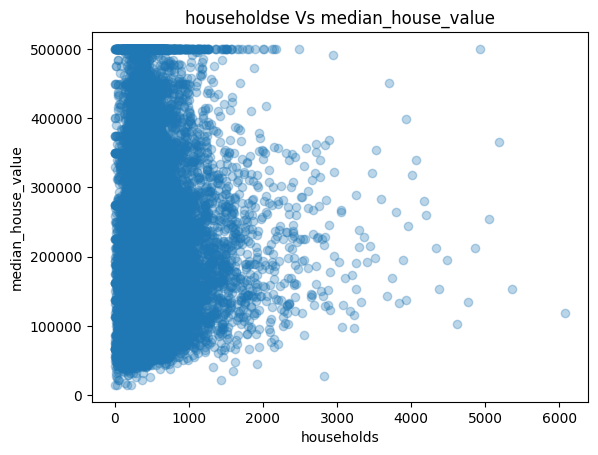

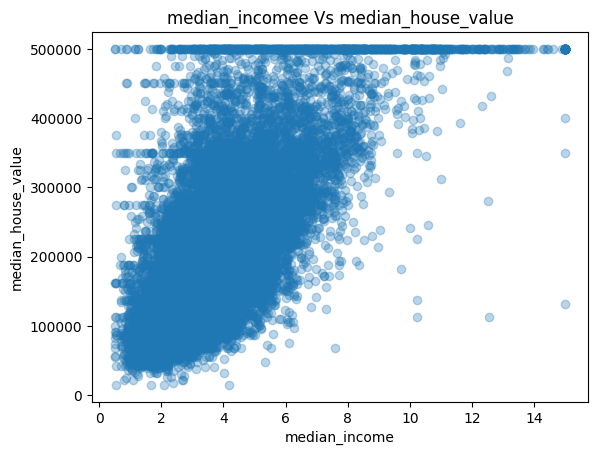

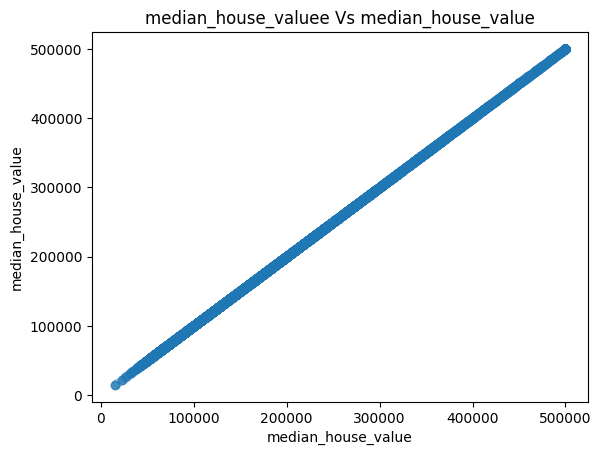

In [394]:
for feature in numerical_features:
    plt.scatter(df[feature], df['median_house_value'], alpha=0.3)
    plt.title(f"{feature}e Vs median_house_value")
    plt.xlabel(feature)
    plt.ylabel('median_house_value')
    plt.show()

In [395]:
print(f"the median_income has a strong relationship with median_house_value with correlation = {mhv['median_income']:0.2f}")
print(f"the all features are nonlinear rather than median_income has a linear relationship with median_house_value")

the median_income has a strong relationship with median_house_value with correlation = 0.69
the all features are nonlinear rather than median_income has a linear relationship with median_house_value


## Correlation Analysis
- What is the correlation matrix between the numerical features?
- Which feature has the strongest positive correlation with MedHouseVal?
- Which feature has the strongest negative correlation with MedHouseVal?
- Are any independent features highly correlated with each other?
- Are there signs of multicollinearity?

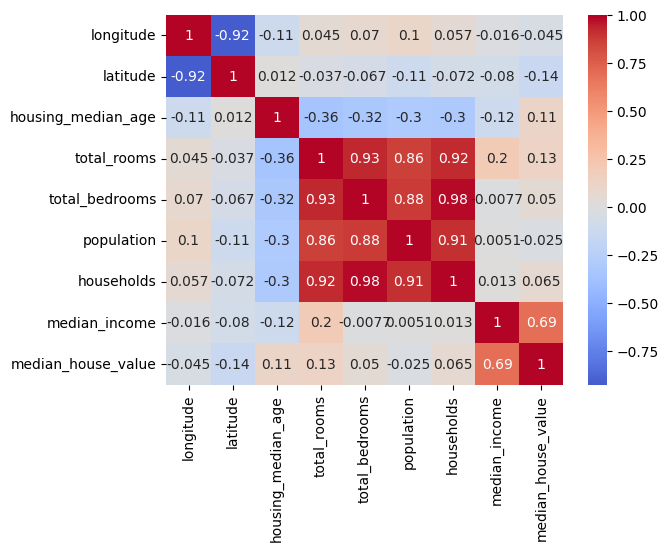

longitude            -0.045398
latitude             -0.144638
housing_median_age    0.106432
total_rooms           0.133294
total_bedrooms        0.049686
population           -0.025300
households            0.064894
median_income         0.688355
Name: median_house_value, dtype: float64

In [396]:
numerical_features_corr = df[numerical_features].corr()
sns.heatmap(numerical_features_corr, annot=True, cmap='coolwarm', center=0)
plt.show()
mhv = numerical_features_corr['median_house_value'].drop(index='median_house_value')
mhv

In [397]:
print(f"""
- the feature with strongest positive correlation with MedHouseVal: {mhv.idxmax()} with {mhv.max():0.2f}
- the feature with strongest negative correlation with MedHouseVal: {mhv.idxmin()} with {mhv.min():0.2f}
- Yes, there are strong 
    - positive relationship between:
        - total_rooms and
            - total_bedrooms
            - population
            - households
        - total_bedrooms
            - population
            - households
        - population
            - households
    - negative relationship between:
        - longitude
            - latitude
- there are signs of multicollinearity between the these features:
    - total_rooms and total_bedrooms (positive)
    - total_rooms and population
    - total_rooms and households
    - total_bedrooms and population
    - total_bedrooms and households
    - population and households
    - longitude and latitude
""")


- the feature with strongest positive correlation with MedHouseVal: median_income with 0.69
- the feature with strongest negative correlation with MedHouseVal: latitude with -0.14
- Yes, there are strong 
    - positive relationship between:
        - total_rooms and
            - total_bedrooms
            - population
            - households
        - total_bedrooms
            - population
            - households
        - population
            - households
    - negative relationship between:
        - longitude
            - latitude
- there are signs of multicollinearity between the these features:
    - total_rooms and total_bedrooms (positive)
    - total_rooms and population
    - total_rooms and households
    - total_bedrooms and population
    - total_bedrooms and households
    - population and households
    - longitude and latitude



## Geographic Analysis
This dataset is especially interesting because it contains latitude and longitude.
- How are house prices distributed geographically?
- Are expensive houses concentrated in particular geographic areas?
- Does MedHouseVal change noticeably with latitude?
- Does MedHouseVal change noticeably with longitude?
- Can a geographic scatter plot reveal patterns that ordinary correlation doesn't?

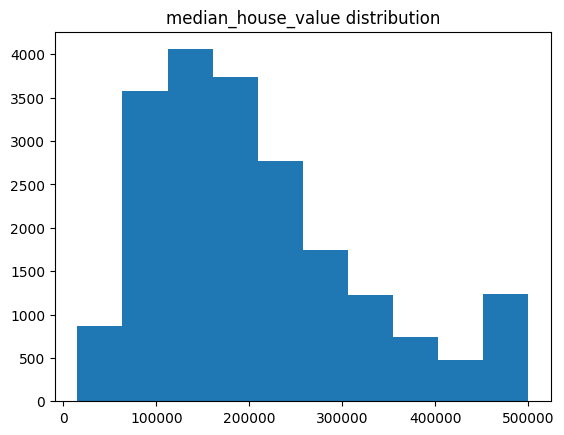

In [398]:
plt.hist(df['median_house_value'])
plt.title('median_house_value distribution')
plt.show()

In [399]:
expensive_houses = df[df['median_house_value'] >= df['median_house_value'].max()]
expensive_houses_coordinates = expensive_houses[['longitude', 'latitude']]
expensive_houses_coordinates

,longitude,latitude
89,-122.27,37.80
459,-122.25,37.87
493,-122.24,37.86
494,-122.24,37.85
509,-122.23,37.83
...,...,...
20422,-118.90,34.14
20426,-118.69,34.18
20427,-118.80,34.19
20436,-118.69,34.21


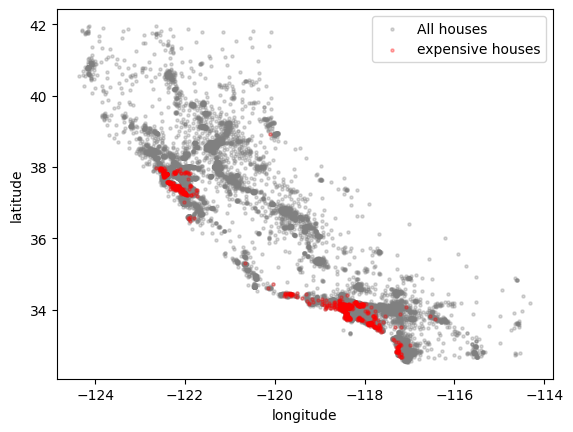


From plotting, we can conclude that most expensive houses are concentrated in specific areas,
particularly along the coastal regions near the San Francisco Bay Area and the Los Angeles / 
Southern California coast, rather than being spread evenly across the state.



In [400]:
plt.scatter(df['longitude'], df['latitude'], c='gray', s=5, alpha=0.3, label = 'All houses')
plt.scatter(expensive_houses_coordinates['longitude'], expensive_houses_coordinates['latitude'], c='red', s=5, alpha=0.3, label = 'expensive houses')
plt.legend()
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()
print("""
From plotting, we can conclude that most expensive houses are concentrated in specific areas,
particularly along the coastal regions near the San Francisco Bay Area and the Los Angeles / 
Southern California coast, rather than being spread evenly across the state.
""")

In [401]:
df[['median_house_value','longitude','latitude']].corr()

,median_house_value,longitude,latitude
median_house_value,1.000000,-0.045398,-0.144638
longitude,-0.045398,1.000000,-0.924616
latitude,-0.144638,-0.924616,1.000000


In [402]:
print("""
MedHouseVal shows only a weak linear relationship with latitude and longitude.
""")


MedHouseVal shows only a weak linear relationship with latitude and longitude.



In [403]:
print("""
Yes, it can. For example, the linear correlation between longitude/latitude and MedHouseVal
is weak, yet the scatter plot of expensive houses reveals a clear non-linear pattern — expensive houses are
concentrated in specific geographic clusters (e.g., the SF Bay Area and LA/Southern California
coast), a pattern that a single correlation coefficient cannot capture.
""")


Yes, it can. For example, the linear correlation between longitude/latitude and MedHouseVal
is weak, yet the scatter plot of expensive houses reveals a clear non-linear pattern — expensive houses are
concentrated in specific geographic clusters (e.g., the SF Bay Area and LA/Southern California
coast), a pattern that a single correlation coefficient cannot capture.



## Outlier Analysis
- Which features contain potential outliers?
- How many outliers are present in each feature using the IQR method?
- Do the outliers significantly affect the mean?
- Do extreme values appear to have a strong influence on the target?

In [404]:
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    large_bound = Q3 + 1.5 * IQR
    small_potential_outliers = df[df[feature] < lower_bound]
    large_potential_outliers = df[df[feature] > large_bound]
    total_outliers = small_potential_outliers.shape[0] + large_potential_outliers.shape[0]
    print(f"the total potential outliers of \033[1m{feature}: {total_outliers}\033[0m")

the total potential outliers of longitude: 0
the total potential outliers of latitude: 0
the total potential outliers of housing_median_age: 0
the total potential outliers of total_rooms: 1290
the total potential outliers of total_bedrooms: 1271
the total potential outliers of population: 1190
the total potential outliers of households: 1210
the total potential outliers of median_income: 670
the total potential outliers of median_house_value: 1064


In [405]:
meanVsmedian = df[['total_rooms', 'total_bedrooms', 'population','households', 'median_income']].agg(['median', 'mean'])
meanVsmedian.loc['diff'] = meanVsmedian.loc['mean'] - meanVsmedian.loc['median']
meanVsmedian.loc['diff'] = meanVsmedian.loc['diff']/meanVsmedian.loc['median'] * 100
meanVsmedian

,total_rooms,total_bedrooms,population,households,median_income
median,2127.000000,435.000000,1166.000000,409.000000,3.536500
mean,2636.504233,537.870553,1424.946949,499.433465,3.871162
diff,23.954125,23.648403,22.208143,22.110872,9.463074


In [406]:
print("""
Looking at the percentage difference between mean and median, outliers appear to significantly
affect the mean for:
- total_rooms
- total_bedrooms
- population
- households
- median_income
""")


Looking at the percentage difference between mean and median, outliers appear to significantly
affect the mean for:
- total_rooms
- total_bedrooms
- population
- households
- median_income



In [407]:
capped_count = (df['median_house_value'] == 500001).sum()
print(f"""
{capped_count} houses ({capped_count/len(df)*100:.1f}%) are capped at exactly $500,001,
indicating this is likely a data collection artifact (top-coding) rather than a true maximum.
This will be addressed during preprocessing before modeling.
""")


958 houses (4.7%) are capped at exactly $500,001,
indicating this is likely a data collection artifact (top-coding) rather than a true maximum.
This will be addressed during preprocessing before modeling.



## Questions Directly Preparing You for Regression
These are the ones I'd definitely include in your project:
- Which features are most useful for predicting MedHouseVal?
- Which features appear to have nonlinear relationships with the target?
- Are there features that should potentially be transformed because of strong skewness?
- Are there extreme values that could negatively affect Linear Regression?
- Based on the EDA, do you expect Linear Regression to perform well? Why or why not?
- Would Polynomial Regression potentially capture relationships that Linear Regression cannot?
- Which features might benefit from polynomial features?
- Are there highly correlated predictors that could cause problems for Linear Regression?

In [408]:
print("""
- Which features are most useful for predicting MedHouseVal?
    - median_income
    - longitude/latitude
Which features appear to have nonlinear relationships with the target?
    - longitude/latitude
Are there features that should potentially be transformed because of strong skewness?
    - total_rooms, total_bedrooms, population, households
""")


- Which features are most useful for predicting MedHouseVal?
    - median_income
    - longitude/latitude
Which features appear to have nonlinear relationships with the target?
    - longitude/latitude
Are there features that should potentially be transformed because of strong skewness?
    - total_rooms, total_bedrooms, population, households



In [409]:
df_copy.shape

(17433, 10)

In [410]:
print("before droping outliers")
numerical_features_corr['median_house_value']

before droping outliers


longitude            -0.045398
latitude             -0.144638
housing_median_age    0.106432
total_rooms           0.133294
total_bedrooms        0.049686
population           -0.025300
households            0.064894
median_income         0.688355
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [411]:
df_copy = df.copy()
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    large_bound = Q3 + 1.5 * IQR
    df_copy = df_copy[(df[feature] > lower_bound) & (df_copy[feature] < large_bound)]

C:\Users\DT 2003\AppData\Local\Temp\ipykernel_15480\1246493488.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy = df_copy[(df[feature] > lower_bound) & (df_copy[feature] < large_bound)]
C:\Users\DT 2003\AppData\Local\Temp\ipykernel_15480\1246493488.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy = df_copy[(df[feature] > lower_bound) & (df_copy[feature] < large_bound)]
C:\Users\DT 2003\AppData\Local\Temp\ipykernel_15480\1246493488.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy = df_copy[(df[feature] > lower_bound) & (df_copy[feature] < large_bound)]
C:\Users\DT 2003\AppData\Local\Temp\ipykernel_15480\1246493488.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_copy = df_copy[(df[feature] > lower_bound) & (df_copy[feature] < large_bound)]
C:\Users\DT 2003\AppData\Local\Temp\ipykernel_15480\1246493488.py:8: UserWarning: Bo

In [412]:
numerical_features_corr_after_droping = df_copy[numerical_features].corr()
print("after droping outliers")
numerical_features_corr_after_droping['median_house_value']

after droping outliers


longitude            -0.042780
latitude             -0.157838
housing_median_age    0.098085
total_rooms           0.191650
total_bedrooms        0.091998
population           -0.011615
households            0.120220
median_income         0.628981
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [413]:
print("""
Are there extreme values that could negatively affect Linear Regression?
    - yes, the columns of households, population, total_bedrooms, total_rooms
Based on the EDA, do you expect Linear Regression to perform well? Why or why not?
    - No, I think non-linear multiple regression with (longitude, latitude, median_income)
Would Polynomial Regression potentially capture relationships that Linear Regression cannot?
    - Yes
Which features might benefit from polynomial features?
    - longitude, latitude
Are there highly correlated predictors that could cause problems for Linear Regression?
    - Yes
        - total_rooms and total_bedrooms (positive)
        - total_rooms and population
        - total_rooms and households
        - total_bedrooms and population
        - total_bedrooms and households
        - population and households
        - longitude and latitude (negative)
""")


Are there extreme values that could negatively affect Linear Regression?
    - yes, the columns of households, population, total_bedrooms, total_rooms
Based on the EDA, do you expect Linear Regression to perform well? Why or why not?
    - No, I think non-linear multiple regression with (longitude, latitude, median_income)
Would Polynomial Regression potentially capture relationships that Linear Regression cannot?
    - Yes
Which features might benefit from polynomial features?
    - longitude, latitude
Are there highly correlated predictors that could cause problems for Linear Regression?
    - Yes
        - total_rooms and total_bedrooms (positive)
        - total_rooms and population
        - total_rooms and households
        - total_bedrooms and population
        - total_bedrooms and households
        - population and households
        - longitude and latitude (negative)



# Feature Engineering

## Cleaning median_house_value through droping the rows whose median_house_value capped at $500,001

Before the droping


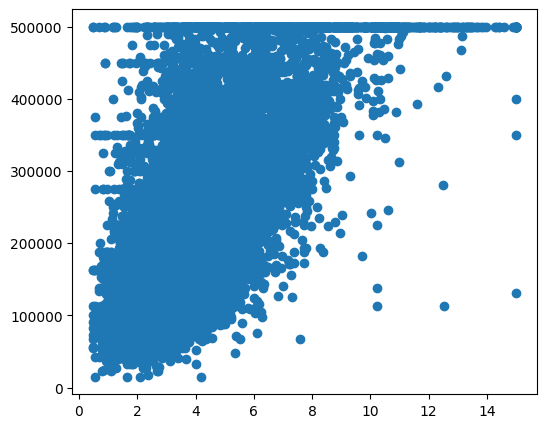

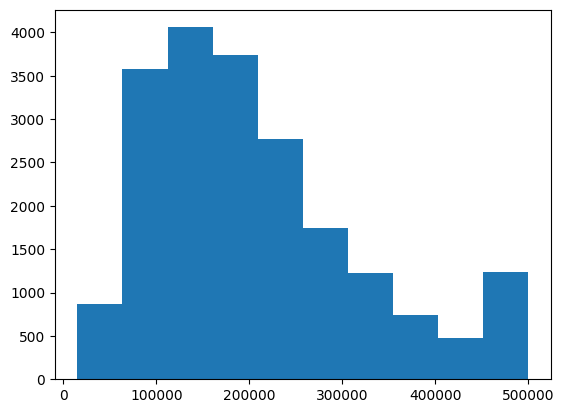

After the droping


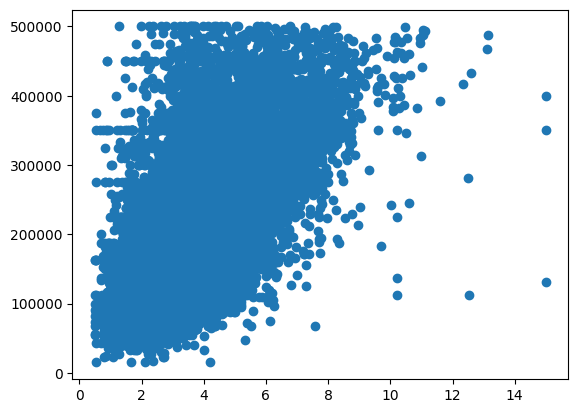

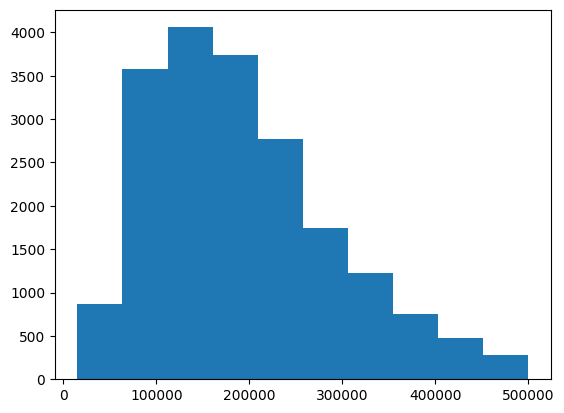

In [414]:
plt.figure(figsize=(6, 5))
print("Before the droping")
plt.scatter(df['median_income'], df['median_house_value'])
plt.show()
plt.hist(df['median_house_value'])
plt.show()
print("After the droping")
plt.scatter(df[df['median_house_value']<500001]['median_income'], df[df['median_house_value']<500001]['median_house_value'])
plt.show()
plt.hist(df[df['median_house_value']<500001]['median_house_value'])
plt.show()
df = df[df['median_house_value']<500001]

In [415]:
print("before droping the rows whose median_house_value capped at $500,001¶")
numerical_features_corr['median_house_value']

before droping the rows whose median_house_value capped at $500,001¶


longitude            -0.045398
latitude             -0.144638
housing_median_age    0.106432
total_rooms           0.133294
total_bedrooms        0.049686
population           -0.025300
households            0.064894
median_income         0.688355
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [416]:
numerical_features_corr = df[numerical_features].corr()
print("after droping the rows whose median_house_value capped at $500,001¶")
numerical_features_corr['median_house_value']

after droping the rows whose median_house_value capped at $500,001¶


longitude            -0.046187
latitude             -0.148637
housing_median_age    0.068595
total_rooms           0.142188
total_bedrooms        0.074672
population            0.011153
households            0.093890
median_income         0.642733
median_house_value    1.000000
Name: median_house_value, dtype: float64

## Combine the redundant independent features (independent features with strong relationship between them)

In [417]:
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['populations_per_household'] = df['population']/df['households']

In [418]:
df['bedrooms_per_room']

0        0.146591
1        0.155797
2        0.129516
3        0.184458
4        0.172096
           ...   
20635    0.224625
20636    0.215208
20637    0.215173
20638    0.219892
20639    0.221185
Name: bedrooms_per_room, Length: 19475, dtype: float64

In [419]:
df = df.drop(columns=['total_rooms', 'total_bedrooms', 'households', 'population'])

In [420]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns

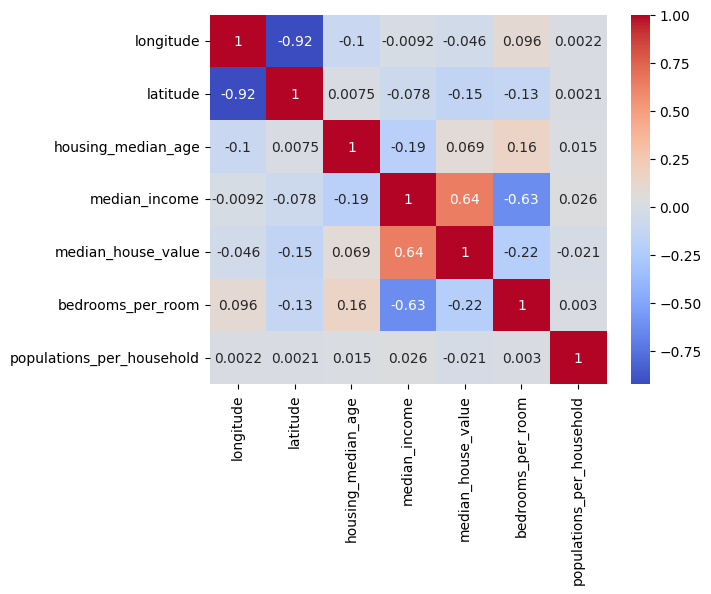

In [426]:
sns.heatmap(df[numerical_features].corr(), cmap='coolwarm', annot=True)
plt.show()

In [427]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'median_income',
       'median_house_value', 'ocean_proximity', 'bedrooms_per_room',
       'populations_per_household'],
      dtype='str')

In [428]:
df.shape

(19475, 8)

In [430]:
df.groupby('ocean_proximity')['median_house_value'].agg(['mean', 'count'])

,mean,count
ocean_proximity,,
<1H OCEAN,224112.933568,8505
INLAND,123331.271603,6469
ISLAND,380440.000000,5
NEAR BAY,236910.832932,2077
NEAR OCEAN,227359.694088,2419


In [530]:
df.shape

(19475, 8)

# Preprocessing

In [570]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias=False)
X_median_income_ploy = poly.fit_transform(df[['median_income']])

In [571]:
from sklearn.model_selection import train_test_split
X_median_income_ploy = pd.DataFrame(X_median_income_ploy, columns=['median_income', 'median_income^2'], index = df.index)
X_ocean_proximity = pd.get_dummies(df['ocean_proximity'])
X = pd.concat([X_median_income_ploy, X_ocean_proximity], axis=1)
Y = df['median_house_value']
X_training, X_testing, y_training, y_testing = train_test_split(X, Y, test_size=0.2, random_state=64)

In [572]:
print(X_median_income_ploy.shape)
print(X_ocean_proximity.shape)
print(df.shape)

print(X_median_income_ploy.index.equals(df.index))
print(X_ocean_proximity.index.equals(df.index))

(19475, 2)
(19475, 5)
(19475, 8)
True
True


# Model

In [575]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_training, y_training)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 34285.94, 58.68,-33951.79,...,177189.13,-17900.29,-19090.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['median_income','median_income^2','<1H OCEAN',...,'ISLAND','NEAR BAY', 'NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.197e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [576]:
from sklearn.metrics import root_mean_squared_error
y_predict = model.predict(X_testing)
RMSE = root_mean_squared_error(y_testing, y_predict)
print(RMSE)

64797.159884457185


# Second model

In [581]:
from sklearn.model_selection import train_test_split
X_ocean_proximity = pd.get_dummies(df['ocean_proximity'])
X = pd.concat([df['median_income'], X_ocean_proximity], axis=1)
Y = df['median_house_value']
X_training, X_testing, y_training, y_testing = train_test_split(X, Y, test_size=0.2, random_state=64)

In [582]:
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_training, y_training)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 34805.06, -33966.33,-106226.25, 177221.7 , -17913.87, -19115.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['median_income','<1H OCEAN','INLAND','ISLAND','NEAR BAY','NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.187e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [583]:
from sklearn.metrics import root_mean_squared_error
y_predict = model2.predict(X_testing)
RMSE = root_mean_squared_error(y_testing, y_predict)
print(RMSE)

64798.16310620927
